# Linear Probing
Linear probing of embeddings generated by Gigapath

## Requirements

In [22]:
import torch
import os 
import deeplake
from torch.utils.data import DataLoader
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from typing import (
    Any,
    Dict, 
    List,
    Tuple,
    Iterable,
    Optional,
    Callable
)
from tqdm import tqdm
import os
from math import inf

import seaborn as sns
import matplotlib.pyplot as plt

import torch
import deeplake
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from torch.optim.lr_scheduler import CosineAnnealingLR

import pyvips

from requirements_emb import (
    get_args,
    set_seed,
    log_device,
    log_metrics,
    embedding_transform_fn,
    Network,
    NetworkHandler,
    CONFIG_DIR,
    BORDER_WIDTH,
    BASE_MODEL_DIR
)


LABEL_MAP = {
    "Stroma": 0,
    "Normal": 1,
    "G3":     2,
    "G4":     3,
    "G5":     4
}




## Training

In [8]:
'''download = False
if download:

    from huggingface_hub import login
    login(token="-")
    
    encoder_dir = os.path.join(BASE_MODEL_DIR, "pre_trained_weights")
    encoder = Network("gigapath", encoder_dir).encoder'''

'download = False\nif download:\n\n    from huggingface_hub import login\n    login(token="-")\n\n    encoder_dir = os.path.join(BASE_MODEL_DIR, "pre_trained_weights")\n    encoder = Network("gigapath", encoder_dir).encoder'

In [9]:

def main():
    log_device()
    num_workers = max(1, (os.cpu_count() // 4))

    arg_path = os.path.join(CONFIG_DIR, "linear_probe.yaml")
    args = get_args(arg_path)
    set_seed(args["seed"])

    # Fixed dataset path
    ds_path = "/home/leolr-int/nfs/transformed_data/new_embeddings/Akoya/mixed_precision/dim_256/Train/gigapath"
    encoder_dir = os.path.join(BASE_MODEL_DIR, "pre_trained_weights")

    # Simplified logging directory
    log_dir = f"/home/leolr-int/nfs/transformed_data/weights/linear_probe_logs/experiment_{args.get('experiment_num', 1)}"
    writer = SummaryWriter(log_dir)
    
    # Fixed weights directory
    model_dir = "/home/leolr-int/nfs/transformed_data/weights"
    os.makedirs(model_dir, exist_ok=True)

    # Load the full dataset
    ds = deeplake.open_read_only(ds_path)
    
    # Use entire dataset as training data
    train_dataset = ds.pytorch(transform=embedding_transform_fn)

    train_loader = DataLoader(
        train_dataset,
        batch_size=args["batch_size"],
        shuffle=True,
        pin_memory=True,
        persistent_workers=True,
        num_workers=num_workers
    )

    # Initialize model - using 'gigapath' as encoder name
    model = Network("gigapath", encoder_dir, args["num_classes"], freeze_encoder=True)
    trainable_params = list(filter(lambda p: p.requires_grad, model.parameters()))

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(trainable_params, lr=args["learning_rate"], weight_decay=args["weight_decay"])
    scheduler = CosineAnnealingLR(optimizer, args["epochs"], eta_min=args["eta_min"])

    network_handler = NetworkHandler(
        model=model,
        criterion=criterion,
        optimizer=optimizer,
        precision=args.get("precision", "mixed"),  # Default to mixed precision
        embedding_mode=True
    )

    min_train_loss = inf
    max_train_accuracy = -inf

    for epoch in range(1, args["epochs"] + 1):
        print("\n" + f"Epoch [{epoch}/{args['epochs']}]".center(BORDER_WIDTH))
        print(f"{'=' * BORDER_WIDTH}\n")

        writer.add_scalar("Learning Rate", scheduler.optimizer.param_groups[0]["lr"], epoch)

        train_loss, train_accuracy = network_handler.train_epoch(train_loader)
        log_metrics(writer=writer, loss=train_loss, prefix="Train", epoch=epoch, performance=train_accuracy)

        # Save best models based on training metrics
        if train_loss < min_train_loss:
            torch.save(model.fc.state_dict(), os.path.join(model_dir, "lowest_train_loss.pth"))
            min_train_loss = train_loss
            print("New minimum training loss — model saved.")
        
        if train_accuracy > max_train_accuracy:
            torch.save(model.fc.state_dict(), os.path.join(model_dir, "highest_train_accuracy.pth"))
            max_train_accuracy = train_accuracy
            print("New maximum training accuracy — model saved.")
            
    
        scheduler.step()

        print(f"{'=' * BORDER_WIDTH}\n")

    # Save final model
    torch.save(model.fc.state_dict(), os.path.join(model_dir, "final_model.pth"))
    print("Final model saved.")

    print("Run Summary:")
    print(f"Min Training Loss: {min_train_loss:.4f} | Max Training Accuracy: {max_train_accuracy:.4f}\n")

        
'''if __name__ == "__main__":
    main()'''

'if __name__ == "__main__":\n    main()'

## Accuracy

In [39]:
def linear_probing(weights_path, dataset):
    
    state_dict = torch.load(weights_path)

    weight = state_dict['head.weight'] # shape: [5, 1536]
    bias = state_dict.get('head.bias', None)  # shape: [5]
   
    EMBEDDING_DIR = f"/home/leolr-int/nfs/transformed_data/new_embeddings/{dataset}"  # or KFBio, etc.
    embedding_path = os.path.join(EMBEDDING_DIR, "mixed_precision", "dim_256", "Train", "gigapath")

    ds = deeplake.open_read_only(embedding_path)
    ds_torch = ds.pytorch(transform=embedding_transform_fn)
    ds_loader = DataLoader(ds_torch, batch_size=64, shuffle=False)  # larger batch_size for efficiency
    weight = weight.cpu()
    bias = bias.cpu()

    all_preds = []
    all_labels = []

    for batch in tqdm(ds_loader, desc="Linear probing"):
        embedding, label, _ = batch  
        
        # Linear probing: logits = embedding @ W^T + b
        logits = embedding @ weight.T + bias

        preds = torch.argmax(F.softmax(logits, dim=1), dim=1)

        all_preds.append(preds)
        all_labels.append(label)

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    # Convert to CPU numpy arrays for sklearn
    y_true = all_labels.cpu().numpy()
    y_pred = all_preds.cpu().numpy()

    return [y_true, y_pred]

def metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)


    print(f" - Accuracy : {acc:.4f}")
    print(f" - Precision: {precision:.4f}")
    print(f" - Recall   : {recall:.4f}")
    print(f" - F1-score : {f1:.4f}")

    labels_name=['Stroma', 'Normal', 'G3', 'G4', 'G5']

    # confusion matrix
    cm = confusion_matrix(y_true, y_pred, normalize='true')    
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, cmap='PuRd',xticklabels=labels_name, yticklabels=labels_name)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()


    



In [11]:
# test on Eric's weight (trained with all data)
'''weights_path = "/home/leolr-int/AGGCPerturbations/model_weights/linear_probe_weights/single_precision/overlap_0.0/dim_256/gigapath/split_1/experiment_1/highest_balanced_accuracy.pth"
linear_probing(weights_path, 'Akoya')
linear_probing(weights_path, 'KFBio')
linear_probing(weights_path, 'KFBio_FDA5')'''

'weights_path = "/home/leolr-int/AGGCPerturbations/model_weights/linear_probe_weights/single_precision/overlap_0.0/dim_256/gigapath/split_1/experiment_1/highest_balanced_accuracy.pth"\nlinear_probing(weights_path, \'Akoya\')\nlinear_probing(weights_path, \'KFBio\')\nlinear_probing(weights_path, \'KFBio_FDA5\')'

In [35]:
# test on my weights (trained only using Subset3_Train_{i}_Akoya)
model_dir = "/home/leolr-int/nfs/transformed_data/weights"
my_weights = os.path.join(model_dir, "final_model.pth")

#linear_probing(my_weights, 'KFBio_WFDA1')
#linear_probing(my_weights, 'KFBio_WFDA5')
#linear_probing(my_weights, 'Akoya')
KFBio_pred=linear_probing(my_weights, 'KFBio')
FDA_CD_pred=linear_probing(my_weights, 'FDA_CD')
#linear_probing(my_weights, 'KFBio_FDA5')
#linear_probing(my_weights, 'KFBio_FDA1')


Linear probing: 100%|█████████████████████████████████████████████████████████████████████████████| 3086/3086 [01:26<00:00, 35.64it/s]


 - Accuracy : 0.8394
 - Precision: 0.8406
 - Recall   : 0.8394
 - F1-score : 0.8385


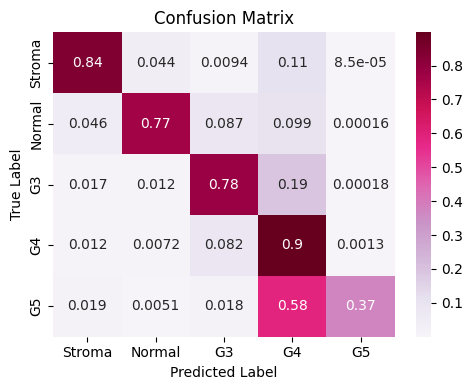

 - Accuracy : 0.8430
 - Precision: 0.8490
 - Recall   : 0.8430
 - F1-score : 0.8427


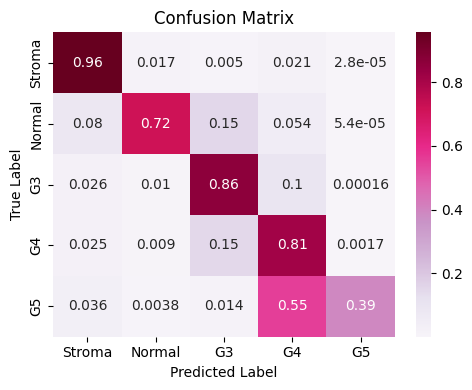

In [40]:
metrics(KFBio_pred[0], KFBio_pred[1])
metrics(FDA_CD_pred[0], FDA_CD_pred[1])